# Quantitative Research Project  
## Mean Reversion Strategy with Volatility Filter

**Author:** IHARDANE Ziyad

---

### Objective

This notebook explores a simple mean-reversion trading strategy using:

- Rolling statistics (mean, std)
- Z-score signals
- Volatility filtering
- Backtesting
- Risk and performance metrics

This is a research prototype, not a production system.

In [14]:
!pip install yfinance pandas numpy matplotlib

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 6)

## 1. Data Collection

We use SPY (S&P 500 ETF) as a proxy for the overall equity market.

This provides:
- diversified exposure
- realistic market behavior
- reduced noise compared to single stocks

In [16]:
data = yf.download("SPY", start="2010-01-01")

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data = data[["Close"]].dropna()

[*********************100%***********************]  1 of 1 completed


## 2. Feature Engineering

We compute:

- Daily returns
- 100-day moving average (trend indicator)
- Rolling volatility (risk indicator)

These features are used to construct the trading signal.

In [17]:
data["returns"] = data["Close"].pct_change()

data["ma_100"] = data["Close"].rolling(100).mean()

data["vol"] = data["returns"].rolling(20).std() * np.sqrt(252)

## 3. Strategy Design

The strategy combines:

### Momentum:
- Go long when price is above the 100-day moving average

### Volatility Filter:
- Avoid trading during high volatility periods

This aims to:
- capture upward trends
- reduce exposure during unstable market conditions

In [18]:
data["signal"] = 0

# Momentum rule
data.loc[data["Close"] > data["ma_100"], "signal"] = 1

# Volatility filter
vol_threshold = data["vol"].quantile(0.8)
data.loc[data["vol"] > vol_threshold, "signal"] = 0

## 4. Backtesting Framework

We simulate the strategy by:

- shifting positions by one day to avoid look-ahead bias
- applying returns to the position

We compare:
- strategy performance
- buy-and-hold benchmark

In [19]:
data["position"] = data["signal"].shift(1).fillna(0)

data["strategy_returns"] = data["position"] * data["returns"]

data["cum_market"] = (1 + data["returns"].fillna(0)).cumprod()
data["cum_strategy"] = (1 + data["strategy_returns"].fillna(0)).cumprod()

## 5. Performance Visualization

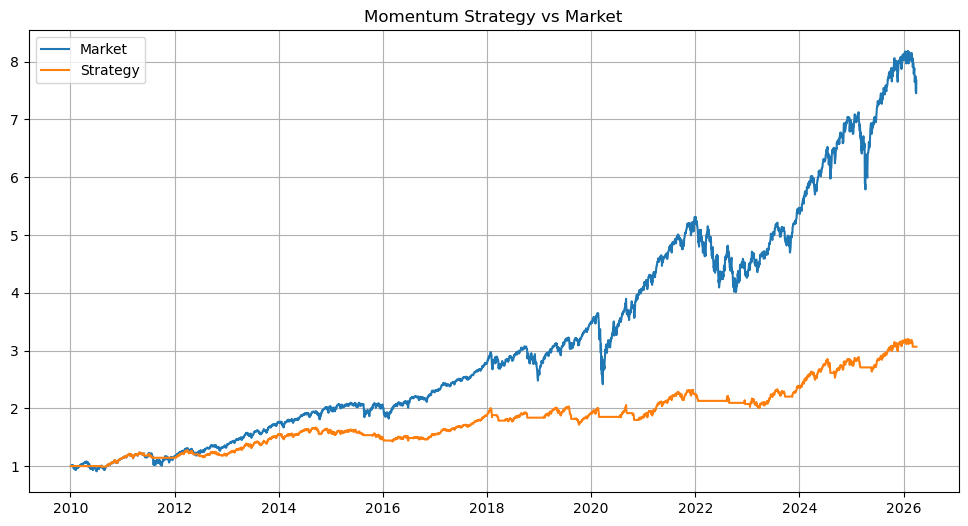

In [20]:
plt.plot(data.index, data["cum_market"], label="Market")
plt.plot(data.index, data["cum_strategy"], label="Strategy")

plt.legend()
plt.title("Momentum Strategy vs Market")
plt.grid(True)
plt.show()

## 6. Performance Metrics

We evaluate the strategy using:

- Annualized return
- Volatility
- Sharpe ratio
- Maximum drawdown

These metrics assess both profitability and risk.

In [21]:
returns = data["strategy_returns"].dropna()

ann_return = returns.mean() * 252
ann_vol = returns.std() * np.sqrt(252)

sharpe = ann_return / ann_vol

drawdown = data["cum_strategy"] / data["cum_strategy"].cummax() - 1
max_dd = drawdown.min()

print("Annual Return:", round(ann_return, 4))
print("Volatility:", round(ann_vol, 4))
print("Sharpe:", round(sharpe, 4))
print("Max Drawdown:", round(max_dd, 4))

Annual Return: 0.074
Volatility: 0.0983
Sharpe: 0.7526
Max Drawdown: -0.1547


In [23]:
market_returns = data["returns"].dropna()

market_ann_return = market_returns.mean() * 252
market_vol = market_returns.std() * np.sqrt(252)
market_sharpe = market_ann_return / market_vol

market_dd = data["cum_market"] / data["cum_market"].cummax() - 1
market_max_dd = market_dd.min()

print("=== STRATEGY ===")
print("Return:", round(ann_return, 3))
print("Sharpe:", round(sharpe, 3))
print("Max DD:", round(max_dd, 3))

print("\n=== MARKET ===")
print("Return:", round(market_ann_return, 3))
print("Sharpe:", round(market_sharpe, 3))
print("Max DD:", round(market_max_dd, 3))

=== STRATEGY ===
Return: 0.074
Sharpe: 0.753
Max DD: -0.155

=== MARKET ===
Return: 0.141
Sharpe: 0.818
Max DD: -0.337


## 7. Interpretation

The goal is not only to outperform the market, but to evaluate:

- risk-adjusted performance
- drawdown behavior
- stability of returns

Momentum strategies are known to perform well in trending markets, while the volatility filter helps reduce exposure during turbulent periods.

## 8. Limitations

- No transaction costs
- No slippage
- Only one asset
- Fixed parameters (not optimized)

## 9. Conclusion

This project demonstrates a simple momentum-based strategy with volatility filtering.

The results show that:
- trend-following can capture market direction
- volatility filtering can improve risk control

This aligns with well-documented empirical evidence in quantitative finance.